# TS4 - Estimacion Espectral 1

In [91]:
import numpy as np
import matplotlib.pyplot as plt

Funciones auxiliares:

In [92]:
def pds_awgn(N, fs, potencia_W):
    tt = np.arange(start = 0, step = 1/fs, stop = N*(1/fs))
    desvio_std = np.sqrt(potencia_W)
    media = 0
    xx = np.random.normal(loc=media, scale=desvio_std, size=N)
    return xx, tt

def pds_sen_ruidosa(nn = 1000, fs = 1000, freq = 1, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = "inf"):
    tt = np.arange(start = 0, step = 1/fs, stop = nn*(1/fs))
    x1 = dc + Amax * np.sin(2*np.pi * freq * tt + phase)

    if SNR_db != "inf" and (type(SNR_db) == float or type(SNR_db) == int):
        pot_senal = 10*np.log10((Amax**2) / 2)
        pot_ruido = pot_senal - SNR_db
        x2, tt = pds_awgn(nn, fs, potencia_W = 10**(pot_ruido/10))
        xx = x1 + x2
    else:
        xx = x1

    return xx, tt

def plot_psd_señal(xx, fs, N, title="Densidad Espectral de Potencia"):
    xx_fft = np.fft.fft(xx)
    freqs = np.fft.fftfreq(N, d=1/fs)

    psd = 2 * (1/(fs*N)) * np.abs(xx_fft)**2

    mask = freqs >= 0
    freqs = freqs[mask]
    psd = psd[mask]

    figure, axs = plt.subplots(2, 1, figsize=(12, 8))
    axs[0].scatter(freqs, psd)
    axs[0].set_xlabel('Frecuencia (Hz)')
    axs[0].set_ylabel('Modulo de X(k) [W]')
    axs[0].grid(True)
    axs[0].set_title(title)


    axs[1].scatter(freqs, 10*np.log10(psd))
    axs[1].set_xlabel('Frecuencia (Hz)')
    axs[1].set_ylabel('Modulo de X[k] [dB]')
    axs[1].grid(True)
    axs[1].set_title("Señal en dB")

    figure.tight_layout()
    plt.show()

    return psd, freqs

Generamos una señal senoidal de potencia unitaria, le aplicamos la FFT y graficamos la densidad espectral de potencia en Watts y en dB:

Tendremos una densidad espectral unitaria: $\Delta F=\frac{Fs}{N} = \frac{100}{100}$

Definimos un factor $k_0$ igual a $\frac{N}{4}$ y definimos la frecuencia de la señal como: $f_0 = k_0 \times \Delta F$

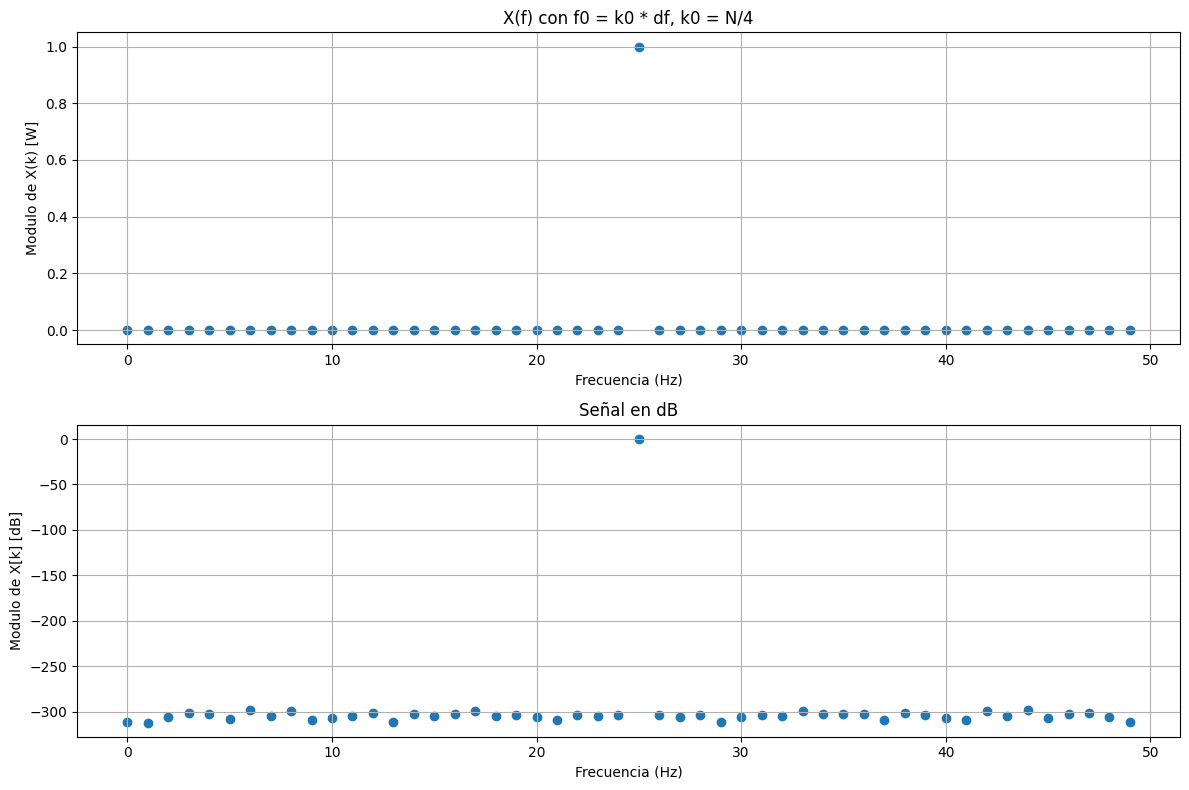

Frecuencias cercanas a f0:
X[20]_dB (20.0 Hz)= -306.1378163004151
X[21]_dB (21.0 Hz)= -309.46772347061
X[22]_dB (22.0 Hz)= -303.6439815830547
X[23]_dB (23.0 Hz)= -304.7989723172916
X[24]_dB (24.0 Hz)= -303.12363559644217
X[25]_dB (25.0 Hz)= 0.0
X[26]_dB (26.0 Hz)= -303.12363559644217
X[27]_dB (27.0 Hz)= -305.57269124531257
X[28]_dB (28.0 Hz)= -303.6439815830547
X[29]_dB (29.0 Hz)= -311.28500118913615


In [93]:
fs = 100
N = 100
res_espectral = fs / N

k0 = N / 4
f0 = k0 * res_espectral

xx, tt = pds_sen_ruidosa(N, fs, freq=f0)
psd, freqs = plot_psd_señal(xx, fs, N, title=f"X(f) con f0 = k0 * df, k0 = N/4")
psd_db = 10*np.log10(psd)

print("Frecuencias cercanas a f0:")
for i in range(len(psd)//2 - 5, len(psd)//2 + 5):
    print(f"X[{i}]_dB ({freqs[i]} Hz)= {psd_db[i]}")

Podemos chequear que la potencia de señal sea realmente 1W, en tiempo y en frecuencia.

Por teorema de Parseval deberian ser iguales.

In [94]:
print(f"Potencia de X(t) = {np.mean(xx**2):.2f} W = {10*np.log10(np.mean(xx**2)):.2f} dB")

print(f"Potencia de X(f) = {np.sum(psd):.2f} W = {10*np.log10(np.sum(psd)):.2f} dB")

Potencia de X(t) = 1.00 W = 0.00 dB
Potencia de X(f) = 1.00 W = 0.00 dB


No se notan diferencias con la teoria de la DFT que vimos hasta ahora.

Ahora vamos a hacer lo mismo con una señal de factor $k_0$ igual a $\frac{N}{4} + 0.25$ y con una frecuencia de señal de: $f_0 = k_0 \times \Delta F$

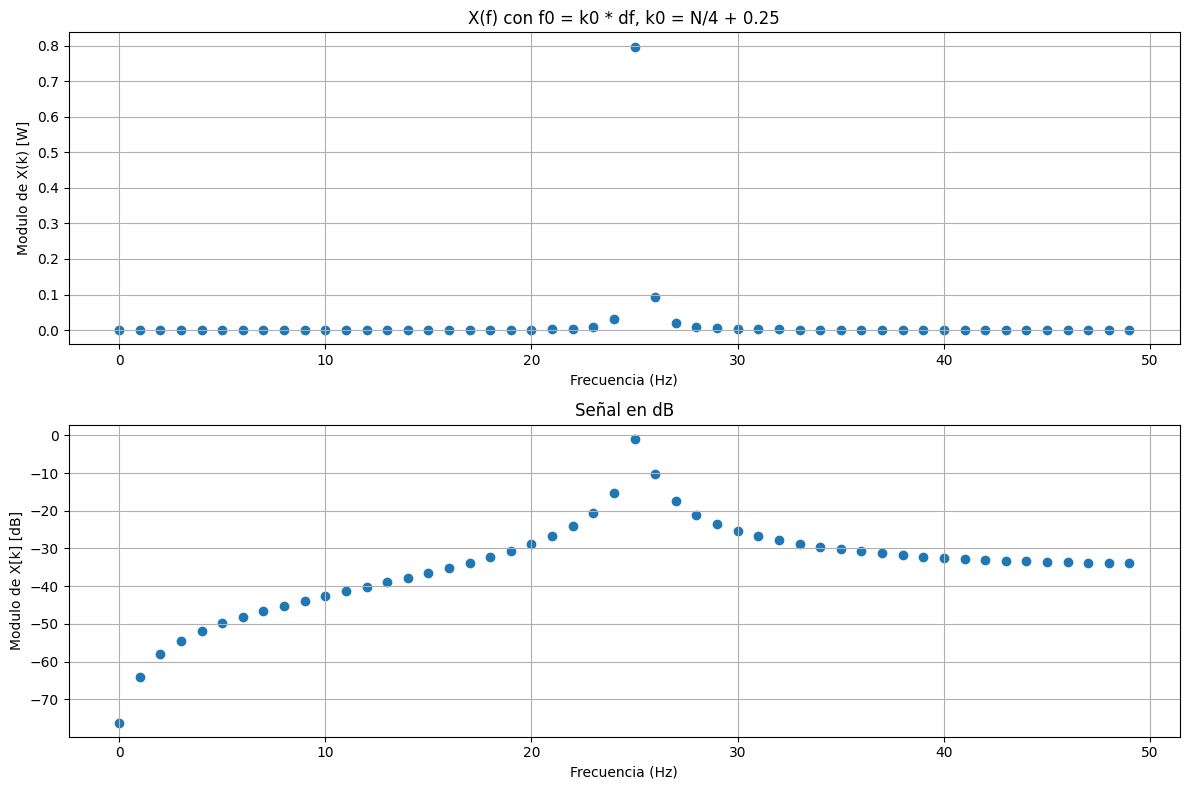

Frecuencias cercanas a f0:
X[20]_dB (20.0 Hz)= -28.89382411651948
X[21]_dB (21.0 Hz)= -26.745210758158695
X[22]_dB (22.0 Hz)= -24.113165679022902
X[23]_dB (23.0 Hz)= -20.62682336162721
X[24]_dB (24.0 Hz)= -15.237198937620231
X[25]_dB (25.0 Hz)= -0.9804892728306701
X[26]_dB (26.0 Hz)= -10.251324722943554
X[27]_dB (27.0 Hz)= -17.3439637818851
X[28]_dB (28.0 Hz)= -21.0067244640765
X[29]_dB (29.0 Hz)= -23.440481722500188


In [95]:
fs = 100
N = 100
res_espectral = fs / N

k0 = N / 4 + .25
f0 = k0 * res_espectral

xx, tt = pds_sen_ruidosa(N, fs, freq=f0)
psd, freqs = plot_psd_señal(xx, fs, N, title=f"X(f) con f0 = k0 * df, k0 = N/4 + 0.25")
psd_db = 10*np.log10(psd)

print("Frecuencias cercanas a f0:")
for i in range(len(psd)//2 - 5, len(psd)//2 + 5):
    print(f"X[{i}]_dB ({freqs[i]} Hz)= {psd_db[i]}")

Podemos chequear que la potencia de señal sea realmente 1W, en tiempo y en frecuencia.

Por teorema de Parseval deberian ser iguales.

In [96]:
print(f"Potencia de X(t) = {np.mean(xx**2):.2f} W = {10*np.log10(np.mean(xx**2)):.2f} dB")

print(f"Potencia de X(f) = {np.sum(psd):.2f} W = {10*np.log10(np.sum(psd)):.2f} dB")

Potencia de X(t) = 0.99 W = -0.04 dB
Potencia de X(f) = 0.99 W = -0.04 dB


Claramente vemos que el espectro no es lo que esperabamos. Al no estar sintonizada la señal de entrada con los bins espectrales de la DFT/FFT tenemos un efecto de spectral leakage. Ahora ya teniendo en cuenta la teoria, tenemos una ventana de muestreo implicita por nuestro sistema, y la señal muestreada no es la señal real en tiempo:

$$

x'(n) = x(n)\times r(n)

$$

La ventana implicita vale 1 para todo n menor a N (cantidad de muestras). Si aplicamos la transformada de fourier:

$$
X'(f) = X(f) * R(f)
$$

Con R(f) siendo el kernel de Dirichlet. Esta convolucion en frecuencia hace que aparezca potencia en bins donde no deberia haber nada. 

Ahora vamos a hacer lo mismo con una señal de factor $k_0$ igual a $\frac{N}{4} + 0.5$ y con una frecuencia de señal de: $f_0 = k_0 \times \Delta F$

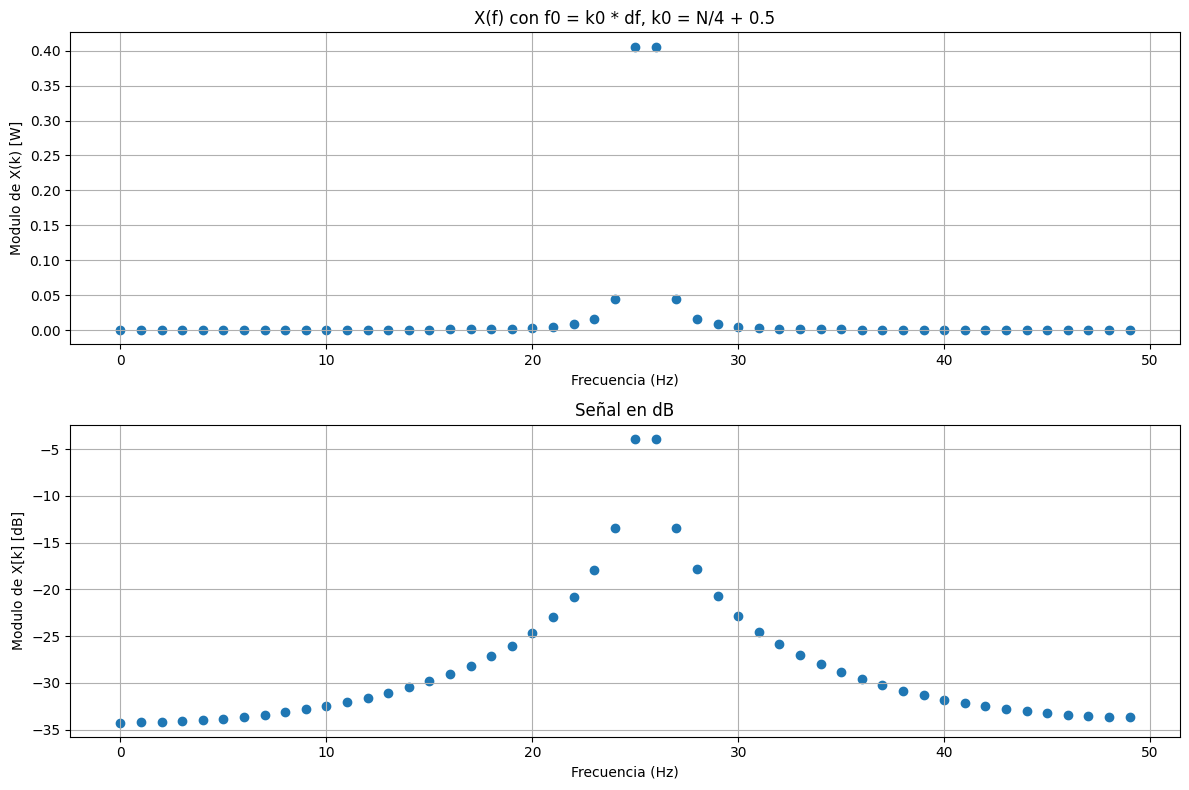

Frecuencias cercanas a f0:
X[20]_dB (20.0 Hz)= -24.62418628302993
X[21]_dB (21.0 Hz)= -22.92996932312345
X[22]_dB (22.0 Hz)= -20.784318795729185
X[23]_dB (23.0 Hz)= -17.887505208437805
X[24]_dB (24.0 Hz)= -13.464823058187774
X[25]_dB (25.0 Hz)= -3.9252557420048335
X[26]_dB (26.0 Hz)= -3.916679585080133
X[27]_dB (27.0 Hz)= -13.439077626671468
X[28]_dB (28.0 Hz)= -17.84453948565052
X[29]_dB (29.0 Hz)= -20.724047303423433


In [97]:
fs = 100
N = 100
res_espectral = fs / N

k0 = N / 4 + .5
f0 = k0 * res_espectral

xx, tt = pds_sen_ruidosa(N, fs, freq=f0)
psd, freqs = plot_psd_señal(xx, fs, N, title=f"X(f) con f0 = k0 * df, k0 = N/4 + 0.5")
psd_db = 10*np.log10(psd)

print("Frecuencias cercanas a f0:")
for i in range(len(psd)//2 - 5, len(psd)//2 + 5):
    print(f"X[{i}]_dB ({freqs[i]} Hz)= {psd_db[i]}")

Podemos chequear que la potencia de señal sea realmente 1W, en tiempo y en frecuencia.

Por teorema de Parseval deberian ser iguales.

In [98]:
print(f"Potencia de X(t) = {np.mean(xx**2):.2f} W = {10*np.log10(np.mean(xx**2)):.2f} dB")

print(f"Potencia de X(f) = {np.sum(psd):.2f} W = {10*np.log10(np.sum(psd)):.2f} dB")

Potencia de X(t) = 1.00 W = -0.00 dB
Potencia de X(f) = 1.00 W = -0.00 dB


Sucede algo similar al caso anterior. Vale la pena aclarar que la potencia de señal se mantiene constante en tiempo y en frecuencia, a pesar del spectral leakage.

## Zero-Padding

Vamos a ver como la tecnica de Zero-Padding afecta a este efecto de spectral leakage. Agregamos 9*N ceros al final de nuestro vector de muestras N y aplicamos el mismo proceso:

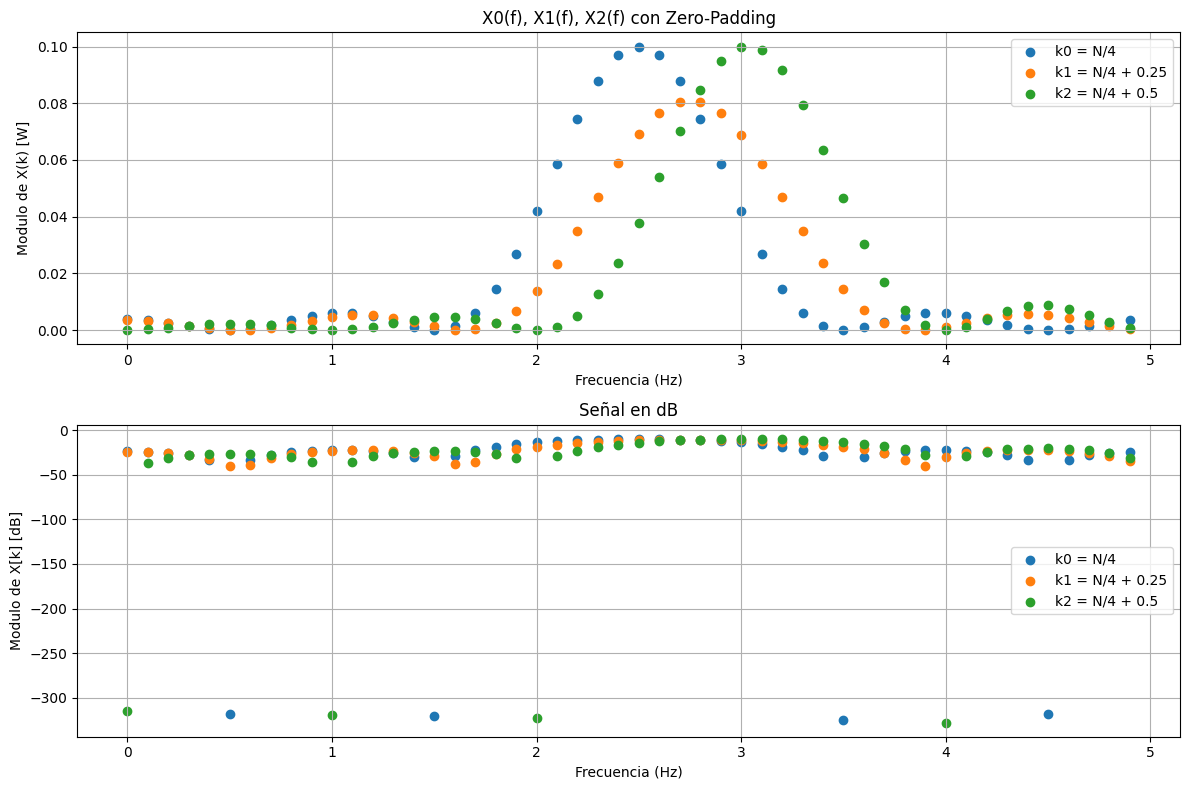

In [103]:
fs = 10
N = 10
res_espectral = fs / N

k0 = N / 4
k1 = N / 4 + .25
k2 = N / 4 + .5

f0 = k0 * res_espectral

f1 = k1 * res_espectral

f2 = k2 * res_espectral

xx0, tt = pds_sen_ruidosa(N, fs, freq=f0)
xx1, tt = pds_sen_ruidosa(N, fs, freq=f1)
xx2, tt = pds_sen_ruidosa(N, fs, freq=f2)

ceros = np.zeros(N*9)

xx0 = np.concatenate((xx0, ceros[:N*9]))
xx1 = np.concatenate((xx1, ceros[:N*9]))
xx2 = np.concatenate((xx2, ceros[:N*9]))


def get_psd(xx, fs):
    xx_fft = np.fft.fft(xx)
    freqs = np.fft.fftfreq(len(xx), d=1/fs)

    psd = 2 * (1/(fs*len(xx))) * np.abs(xx_fft)**2
    mask = freqs >= 0
    freqs = freqs[mask]
    psd = psd[mask]

    return psd, freqs

psd1, freqs1 = get_psd(xx0, fs)
psd2, freqs2 = get_psd(xx1, fs)
psd3, freqs3 = get_psd(xx2, fs)

figure, axs = plt.subplots(2, 1, figsize=(12, 8))
axs[0].scatter(freqs1, psd1, label="k0 = N/4")
axs[0].scatter(freqs2, psd2, label="k1 = N/4 + 0.25")
axs[0].scatter(freqs3, psd3, label="k2 = N/4 + 0.5")
axs[0].set_xlabel('Frecuencia (Hz)')
axs[0].set_ylabel('Modulo de X(k) [W]')
axs[0].grid(True)
axs[0].set_title("X0(f), X1(f), X2(f) con Zero-Padding")
axs[0].legend()


axs[1].scatter(freqs1, 10*np.log10(psd1), label="k0 = N/4")
axs[1].scatter(freqs2, 10*np.log10(psd2), label="k1 = N/4 + 0.25")
axs[1].scatter(freqs3, 10*np.log10(psd3), label="k2 = N/4 + 0.5")
axs[1].set_xlabel('Frecuencia (Hz)')
axs[1].set_ylabel('Modulo de X[k] [dB]')
axs[1].grid(True)
axs[1].set_title("Señal en dB")
axs[1].legend()
figure.tight_layout()
plt.show()